# Xarray 

<!-- ![](http://xarray.pydata.org/en/stable/_static/dataset-diagram-logo.png) -->

In this lesson we are going to learn about the `Xarray` library - one of the most useful libraries available to us as earth/ocean/atmospheric researchers.

### credit 

This lesson is from the Geohackweek tutorial on Xarray (https://geohackweek.github.io/nDarrays/), and  Abernathy's book: (https://earth-env-data-science.github.io/lectures/xarray/xarray_intro.html). 

### Think of Xarray as a bit like numpy, except that it has a better 'understanding' of the dimensions of your data.

## Multidimensional Arrays 
(not as scary as they sound)

### Like a table in Excel but with more than two dimensions

Let's start by drawing some 2D arrays (familiar spreadsheets) on the board. List a bunch of types of data that might fit in that format. 

Now extend this idea: what are common examples of 3D arrays? What type of ocean/earth/atmos data might fit this format? Can we see how they are easily related to 2D arrays?



In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
da = xr.DataArray([2,3,6,7,8])
da

<xarray.DataArray (dim_0: 5)> Size: 40B
array([2, 3, 6, 7, 8])
Dimensions without coordinates: dim_0


In [ ]:
da = xr.DataArray([2,3,6,7,8], dims=['time'])
da


<xarray.DataArray (time: 5)> Size: 40B
array([2, 3, 6, 7, 8])
Dimensions without coordinates: time


# What is Xarray?

Xarray is a python library that brings the convienient features of Pandas to higher dimensions. It was initally developed by people at the Climate Corporation for dealing with climate data. It turns out it's very useful in much of our work. 

Like Pandas, Xarray let's us do operations on named dimensions. It keeps a lot of the 'metadata' associted with the actually data that makes plotting, calculating, and grouping much easier. 

It also is a great way to load data formats that we will see a lot in our work, in particular NetCDFs (more on this later). 


features:

the `DataArray` is Xarray’s standard data type: a labeled, multi-dimensional array

the `DataArray` has these key properties:

* `data`: N-dimensional array (NumPy or dask) holding the array’s values, i.e. your actual data,

* `dims`: dimension names for each axis, just the names, like 'latitude' or 'longitude' or 'time'

* `coords`: dictionary-like container of arrays that label each point, i.e. the actual values of each axis like time or latitue or something

* `attrs`: ordered dictionary holding metadata, or 'attributes',  like the data units, person who collected, any of that stuff


The second main data structure is the `Dataset` - which you can think of as a group of `DataArray`, like perhaps a grid that has a temperature `DataArray`, a salinity `DataArray`, and an oxygen `DataArray` that are all from the same instument or model and belong together. These can be housed within one `Dataset`. We will show this later


# When to use Xarray?

* if your data are multidimensional, like lat, lon, x, y, z, time ...
* if your data are on a regular grid (output from a model)
* if your data are contained in a `.nc` netcdf file.

![](dataset-diagram.png)

# What can Xarray do for *me*?

Think about how you would want to build a data structure. Let's go through on the board all the things that should go along with your data. For concretness let's think about the temperature at all depths and points in the mid-Atlantic Bight, from a model say. What do we need to know? We can name all those vectors, but wouldn't it be easier if they all lived with the data itself??

# Build a simple DataArray

That is maybe a lot of complex info. Let's start from the basic basics and build up our own `DataArray` using Xarray to see how all it's parts work

We will start with some fake data, just a sequence of numbers. Make up something about what they are. 

We need to download xarray using `conda` like we have before:

In terminal, activate your conda env. Then do `conda install xarray`


Of course, to start we need to import xarray. To save typing we usualy ask python to call xarray 'xr'



In [12]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Now let's use the `xr.DataArray()` function to make our fake dataarray

In [14]:
da = xr.DataArray([2,3,6,7,8])
da

print(da)

<xarray.DataArray (dim_0: 5)> Size: 40B
array([2, 3, 6, 7, 8])
Dimensions without coordinates: dim_0


Ok, that is just some data, a few numbers. So far this isn't anything more special than a numpy array. But it'll get better if we can give it some dimensions and coordinates that give the data context. Maybe those are the number of birds we counted at 10 minute intervals while we were staring out the window in class.

Let's add the dimention `time` to the DataArray:

In [15]:
da = xr.DataArray([2,3,6,7,8], dims=['time'])
da

<xarray.DataArray (time: 5)> Size: 40B
array([2, 3, 6, 7, 8])
Dimensions without coordinates: time

Ok, now we know that the data correspond to times, that's good. It's giving us a more complete understanding of the context of the data. But what times? 

We've named the dimension, but now let's give it some coordinates, in otherwords let's specify the exact times when we measured those birds. 

In order to connect the dimension to an actual set of time points (i.e. coordinates) we need to recall a Python data type we talked about a while ago. 

## Quick Aside: Dictionaries  - remember that python data type?
Quick summary: A Dictionary is a lot like a list, but it has a label for each element in the list. Namely a Dictionary is made up of key : values pairs. You can think of it literally like a dictonary: you'd look something by it's name (key) and there would be other information in there (the values). We define a ditionary uscing curly brackets: `dict = {}` and we separate keys from their values with a colon `:`


``` python
d = {
    <key>: <value>,
    <key>: <value>,
      .
      .
      .
    <key>: <value>
}
```

For example we can make a dictionary where the key is a city, and the value is that city's baseball team:

``` python
MLB_team = {
     'Colorado' : 'Rockies',
     'Boston'   : 'Red Sox',
     'Minnesota': 'Twins',
     'Milwaukee': 'Brewers',
     'Seattle'  : 'Mariners'
 }
```


Dictionaries aren't too complicated, they are just another way of storing data. We will use them a lot with xarrays. 




One use case we can talk about now, we have decided the dimension of our DataArray is time, and we can use a dictionary to associate that key (time) with values ( t1, t2, t3, etc).

We've named the dimension, but now let's give it some coordinates, in otherwords let's specify the exact times when we measured those birds. Just to be simple we will say starting at 0 minutes we looked out every 10 minutes to count the birds.

When we specify the coordinates, we need to tell xarray that we are refering to the `time` dimention, and then tell it what times we want to include:

In [ ]:
da = xr.DataArray([2,3,6,7,8], dims=['time'], coords = {'time':[1,2,3,4,5]})
da

ValueError: different number of dimensions on data and dims: 1 vs 2

In [27]:
da = xr.DataArray([2,3,6,7,8], dims=['time'], coords = {'time':range(5)}) # can use this or the one above but they are the same
da

<xarray.DataArray (time: 5)> Size: 40B
array([2, 3, 6, 7, 8])
Coordinates:
  * time     (time) int64 40B 0 1 2 3 4

In [23]:
da.attrs = {'units':'bird observations', 'time':'minutes'} #replce units with data to remove from yaxis of plot below
da

<xarray.DataArray (time: 5)> Size: 40B
array([2, 3, 6, 7, 8])
Coordinates:
  * time     (time) int64 40B 0 1 2 3 4
Attributes:
    units:    bird observations
    time:     minutes

Now we have something that pretty much fully describes our experiment (almost, what might we be missing? what about attributue? can you think of some examaples?) 

From here Xarray has all sorts of built in functions that allow you to interact with your data quickly. Because the DataArray has data, dimentions, and coordinates, Xarray can internally understand a lot about the data. 

One thing we can do is just ask xarray to make a simple plot. This takes almost no code:

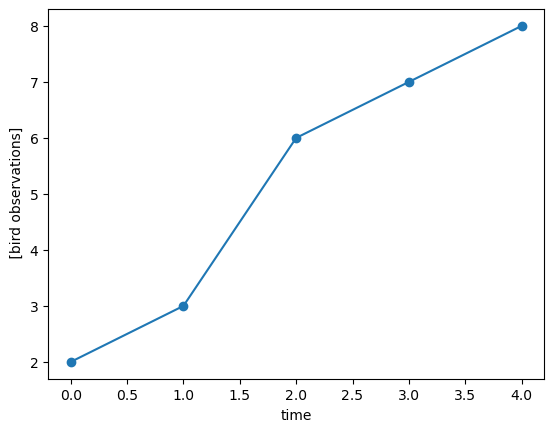

In [24]:
da.plot(marker='o');

In [ ]:
da.plot? # So this is the arguments that it takes 

Signature:     
da.plot(
    *,
    row: 'Hashable | None' = None,
    col: 'Hashable | None' = None,
    col_wrap: "int | Literal['auto'] | None" = None,
    ax: 'Axes | None' = None,
    hue: 'Hashable | None' = None,
    subplot_kws: 'dict[str, Any] | None' = None,
    **kwargs: 'Any',
) -> 'Any'
Type:           DataArrayPlotAccessor
String form:    <xarray.plot.accessor.DataArrayPlotAccessor object at 0x70b73282a5c0>
File:           ~/miniforge3/envs/spear-env/lib/python3.11/site-packages/xarray/plot/accessor.py
Docstring:     
Default plot of DataArray using :py:mod:`matplotlib:matplotlib.pyplot`.

Calls xarray plotting function based on the dimensions of
the squeezed DataArray.

=============== ===========================
Dimensions      Plotting function
=============== ===========================
1               :py:func:`xarray.plot.line`
2               :py:func:`xarray.plot.pcolormesh`
Anything else   :py:func:`xarray.plot.hist`
=============== ===========================

P

The end...

# Breakout / exercise 01

# Build a mulidimentional DataArray


We made up some data in the simple example. Also, did you notice it's just one dimentional? Let's go through the excercise by building some a multidimentional dataset.

This is in the next notebook

In [ ]:
testing_data = np.array([
    #t #t #t
    [1, 2, 3,], # Space
    [4, 5, 6], # Space
    [7, 8, 9]
])

xr.DataArray(testing_data, dims = ["space", "time"], coords = {"space": [5, 10, 15], "time": [1, 2, 3]})

# Alright, so you have to know that DataArrays are much more stricts when defining them, in that the matricies must lign up pretty well
# Now for DataSETS which is a collection of DataArrays, the reality is not as strict
# This is because DataSETS are kind of like buckets that hold a bunch of dataarrays, so if you add another dimension when the # of DataArrays doesn't require it, then the program is just assuming you're going to add one later


<xarray.DataArray (space: 3, time: 3)> Size: 72B
array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])
Coordinates:
  * space    (space) int64 24B 5 10 15
  * time     (time) int64 24B 1 2 3